# Identitas Diri
- Nama: Muhammad Abiya Makruf
- Username: Abiyamf

## Import library

In [90]:
import random

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf


In [91]:
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

## Data loading & Eksplorasi Data

In [92]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
raw_df = pd.read_csv(csv_url)

In [93]:
raw_df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [94]:
raw_df.tail()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
53145,2023-10-19 19:00:00,28750.75,2.984059e+07,53.630054,109.926882,129.065981,7.459700
53146,2023-10-19 20:00:00,28715.38,4.997623e+07,53.531282,111.721905,129.268969,7.118597
53147,2023-10-19 21:00:00,28604.09,3.205666e+07,53.221944,113.055031,129.287930,6.210037
53148,2023-10-19 22:00:00,28649.65,2.200420e+07,53.332673,114.513131,129.219782,6.515616
53149,2023-10-19 23:00:00,28713.71,1.758298e+07,53.487941,116.161806,129.096002,6.963753


In [95]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


In [96]:
# Penentuan feature dan target
FEATURE = [i for i in raw_df.columns if i != 'Date']
TARGET = 'Close'

print("feature:", FEATURE)
print("target:", TARGET)

feature: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
target: Close


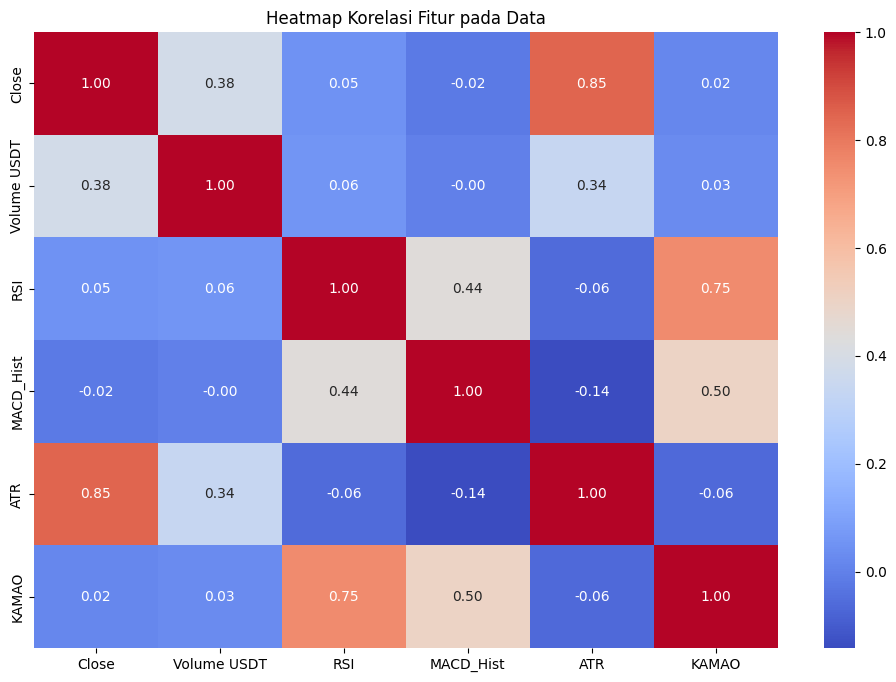

In [97]:
# Visualisasi heatmap korelasi antar fitur
plt.figure(figsize=(12, 8))
sns.heatmap(raw_df[[i for i in raw_df.columns if i != "Date"]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur pada Data')
plt.show()

## Data preparation

In [98]:
df = raw_df.copy()

In [99]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').drop_duplicates(subset=['Date']).reset_index(drop=True)

In [100]:
ROLLING_WINDOW = 24
def add_rolling_features(df, target_column=TARGET, rolling_window=ROLLING_WINDOW):
    enriched = df.copy()
    enriched['close_roll_mean_24'] = enriched[target_column].rolling(rolling_window, min_periods=rolling_window).mean()
    enriched['close_roll_std_24'] = enriched[target_column].rolling(rolling_window, min_periods=rolling_window).std()
    enriched = enriched.dropna().reset_index(drop=True)
    return enriched

df = add_rolling_features(df)
FEATURE += ['close_roll_mean_24', 'close_roll_std_24']

In [101]:
# Split data
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

train_df = df.iloc[:int(len(df) * TRAIN_RATIO)].reset_index(drop=True)
val_df = df.iloc[int(len(df) * TRAIN_RATIO):int(len(df) * (TRAIN_RATIO + VAL_RATIO))].reset_index(drop=True)
test_df = df.iloc[int(len(df) * (TRAIN_RATIO + VAL_RATIO)):].reset_index(drop=True)

len(train_df), len(val_df), len(test_df)

(11650, 2496, 2497)

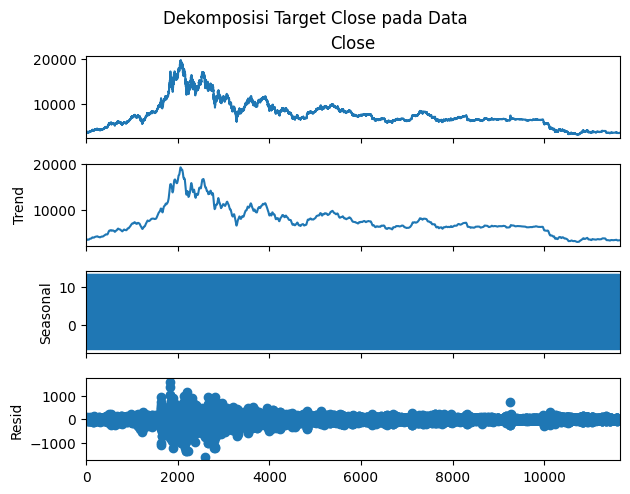

In [102]:
# Analisis dekomposisi untuk melihat komponen tren, musiman, dan residu
decomposition = seasonal_decompose(train_df[TARGET], model='additive', period=24)
decomposition.plot()
plt.suptitle('Dekomposisi Target Close pada Data', y=1.02)
plt.show()

,lag,acf,pacf,score,significant
0,24,0.982794,-0.027819,0.982794,True
1,48,0.966817,0.001694,0.966817,True
2,72,0.950498,-0.019747,0.950498,True
3,96,0.934422,-0.007910,0.934422,True
4,168,0.886990,0.018820,0.886990,True


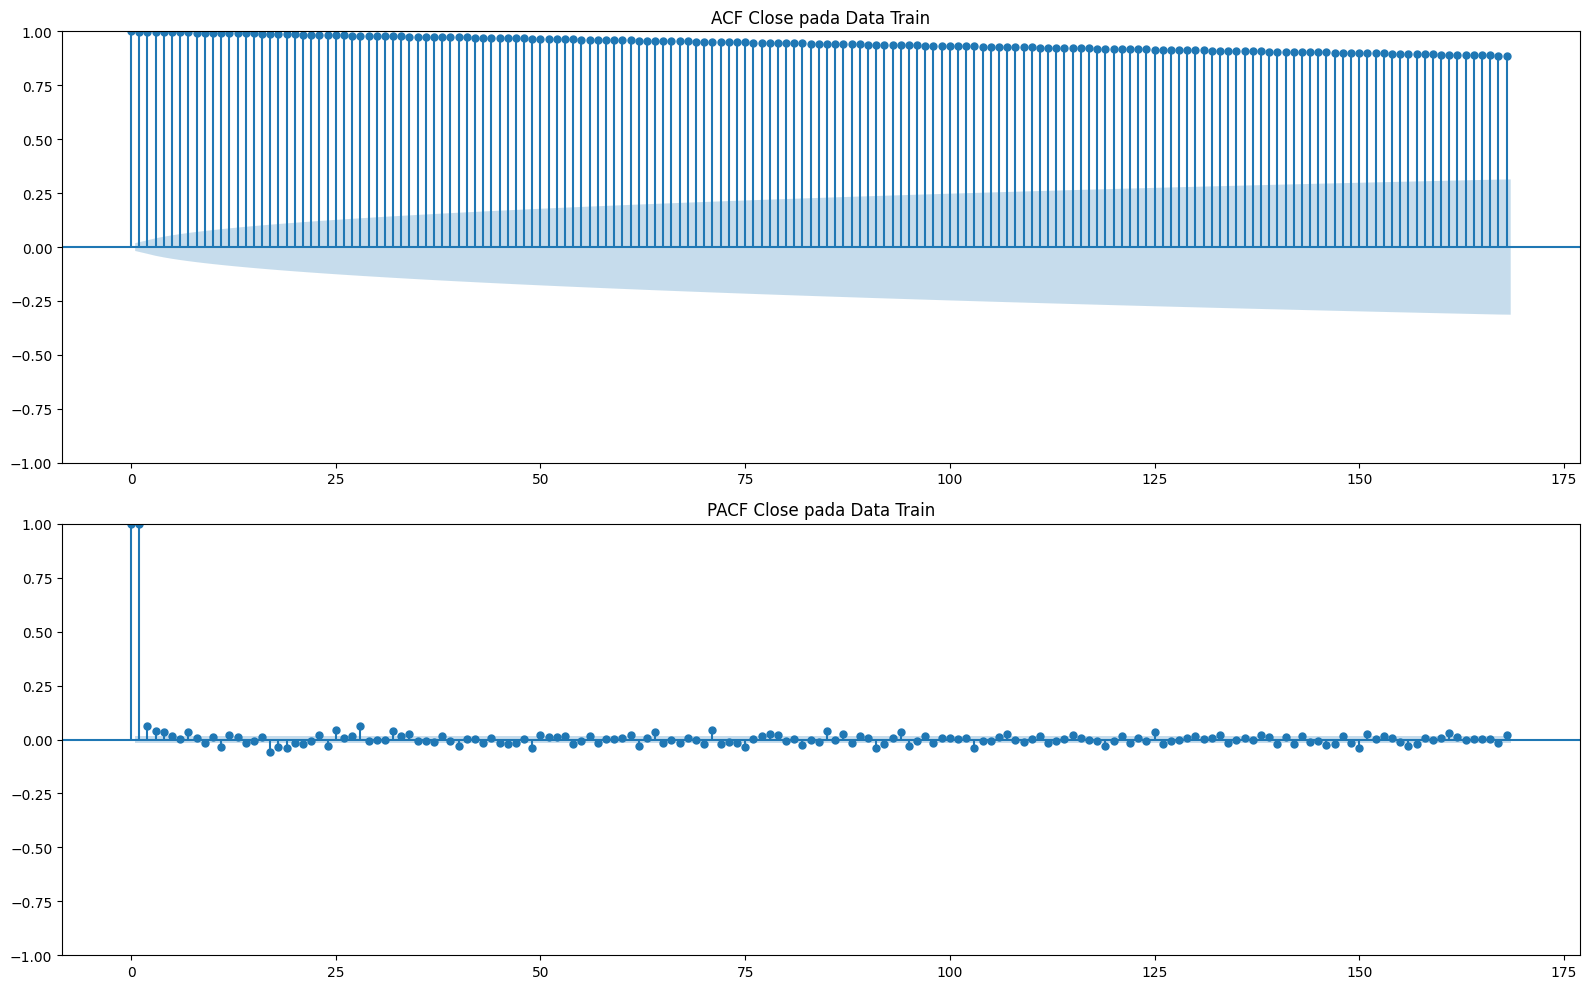

Significance threshold: 0.01816
Selected window size from ACF/PACF analysis: 24


In [103]:
WINDOW_CANDIDATES = (24, 48, 72, 96, 168)
def select_window_size_from_lag_analysis(series, candidate_windows=WINDOW_CANDIDATES):
    max_lag = max(candidate_windows)
    acf_values = acf(series, nlags=max_lag, fft=True)
    pacf_values = pacf(series, nlags=max_lag, method='ywm')
    significance_threshold = 1.96 / np.sqrt(len(series))

    lag_rows = []
    selected_window = 72
    for lag in candidate_windows:
        acf_at_lag = float(acf_values[lag])
        pacf_at_lag = float(pacf_values[lag])
        score = max(abs(acf_at_lag), abs(pacf_at_lag))
        lag_rows.append({
            'lag': lag,
            'acf': acf_at_lag,
            'pacf': pacf_at_lag,
            'score': score,
            'significant': score >= significance_threshold,
        })
        if score >= significance_threshold and selected_window == 72:
            selected_window = lag

    lag_summary = pd.DataFrame(lag_rows)
    return selected_window, significance_threshold, lag_summary
selected_window_size, significance_threshold, lag_summary_df = select_window_size_from_lag_analysis(train_df[TARGET])
display(lag_summary_df)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
plot_acf(train_df[TARGET], lags=max(WINDOW_CANDIDATES), ax=axes[0])
plot_pacf(train_df[TARGET], lags=max(WINDOW_CANDIDATES), ax=axes[1], method='ywm')
axes[0].set_title('ACF Close pada Data Train')
axes[1].set_title('PACF Close pada Data Train')
plt.tight_layout()
plt.show()

print(f'Significance threshold: {significance_threshold:.5f}')
print(f'Selected window size from ACF/PACF analysis: {selected_window_size}')

In [104]:
# Scale data
scalers = {}
for col in FEATURE :
    scaler = MinMaxScaler()
    scaler.fit(train_df[[col]])
    scalers[col] = scaler

for col in FEATURE :
    train_df[col] = scalers[col].transform(train_df[[col]])
    val_df[col] = scalers[col].transform(val_df[[col]])
    test_df[col] = scalers[col].transform(test_df[[col]])


In [105]:
train_df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,close_roll_mean_24,close_roll_std_24
0,2017-09-22 08:00:00,0.028762,0.000748,0.467362,0.554935,0.141062,0.512444,0.031060,0.079898
1,2017-09-22 09:00:00,0.026298,0.000816,0.461314,0.554729,0.140841,0.502376,0.030401,0.076574
2,2017-09-22 10:00:00,0.024236,0.001163,0.456266,0.554443,0.140576,0.493985,0.029623,0.072440
3,2017-09-22 11:00:00,0.022248,0.001473,0.451406,0.554082,0.140531,0.485951,0.028777,0.068786
4,2017-09-22 12:00:00,0.025401,0.000974,0.459685,0.553869,0.140488,0.498994,0.028085,0.060539


In [106]:
WINDOW_SIZE = selected_window_size
HORIZON = 24

def make_supervised_windows(df, feature_columns, target_column, window_size, horizon=HORIZON):
    feature_values = df[feature_columns].to_numpy(dtype=np.float32)
    target_values = df[target_column].to_numpy(dtype=np.float32)
    timestamps = df['Date'].to_numpy()
    target_index = feature_columns.index(target_column)

    X, y, y_timestamps, last_close_values = [], [], [], []
    for end_idx in range(window_size, len(df) - horizon + 1):
        start_idx = end_idx - window_size
        target_slice = slice(end_idx, end_idx + horizon)
        X.append(feature_values[start_idx:end_idx])
        y.append(target_values[target_slice].reshape(horizon, 1))
        y_timestamps.append(timestamps[target_slice])
        last_close_values.append(feature_values[end_idx - 1, target_index])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    y_timestamps = np.asarray(y_timestamps)
    last_close_values = np.asarray(last_close_values, dtype=np.float32)
    return X, y, y_timestamps, last_close_values

X_train, y_train, train_timestamps, train_last_close = make_supervised_windows(train_df, FEATURE, TARGET, WINDOW_SIZE)
X_val, y_val, val_timestamps, val_last_close = make_supervised_windows(val_df, FEATURE, TARGET, WINDOW_SIZE)
X_test, y_test, test_timestamps, test_last_close = make_supervised_windows(test_df, FEATURE, TARGET, WINDOW_SIZE)

In [107]:
def build_decoder_inputs(y_true, last_close_values):
    decoder_inputs = np.zeros_like(y_true, dtype=np.float32)
    decoder_inputs[:, 0, 0] = last_close_values
    decoder_inputs[:, 1:, 0] = y_true[:, :-1, 0]
    return decoder_inputs

train_decoder_inputs = build_decoder_inputs(y_train, train_last_close)
val_decoder_inputs = build_decoder_inputs(y_val, val_last_close)
test_decoder_inputs = build_decoder_inputs(y_test, test_last_close)

In [108]:
BATCH_SIZE = 64
EPOCHS = 10

def make_tf_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(X), 2048), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_tf_dataset(X_train, y_train, shuffle=True)
val_ds = make_tf_dataset(X_val, y_val, shuffle=False)
test_ds = make_tf_dataset(X_test, y_test, shuffle=False)

In [109]:
def make_seq2seq_tf_dataset(encoder_inputs, decoder_inputs, targets, batch_size=BATCH_SIZE, shuffle=False):
    inputs = {
        'encoder_inputs': encoder_inputs.astype(np.float32),
        'decoder_inputs': decoder_inputs.astype(np.float32),
    }
    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(encoder_inputs), 2048), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset
train_seq2seq_ds = make_seq2seq_tf_dataset(X_train, train_decoder_inputs, y_train, shuffle=True)
val_seq2seq_ds = make_seq2seq_tf_dataset(X_val, val_decoder_inputs, y_val, shuffle=False)
test_seq2seq_ds = make_seq2seq_tf_dataset(X_test, test_decoder_inputs, y_test, shuffle=False)

## Baseline LSTM (Untuk kriteria 1 advanced)

In [110]:
baseline_lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(WINDOW_SIZE, len(FEATURE))),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(HORIZON),
    tf.keras.layers.Reshape((HORIZON, 1)),
], name='Baseline_LSTM_Model')

baseline_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError()],
)

history_lstm_baseline = baseline_lstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

test_loss, test_mae = baseline_lstm_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

Epoch 1/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0101 - mean_absolute_error: 0.0434 - val_loss: 9.9864e-05 - val_mean_absolute_error: 0.0070
Epoch 2/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7493e-04 - mean_absolute_error: 0.0152 - val_loss: 5.8288e-05 - val_mean_absolute_error: 0.0054
Epoch 3/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.5730e-04 - mean_absolute_error: 0.0153 - val_loss: 5.6359e-05 - val_mean_absolute_error: 0.0057
Epoch 4/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.8302e-04 - mean_absolute_error: 0.0144 - val_loss: 4.6137e-05 - val_mean_absolute_error: 0.0046
Epoch 5/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.4910e-04 - mean_absolute_error: 0.0138 - val_loss: 4.3562e-05 - val_mean_absolute_error: 0.0043
Epoch 6/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.5010e-04 - mean_absolute_error: 0.0140 - val_loss: 4.5263e-05 - val_mean_absolute_error: 0.0046
Epoch 7/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - lo

In [111]:
sample_prediction = baseline_lstm_model.predict(X_test[:1], verbose=0)[0, :, 0]
sample_actual = y_test[0, :, 0]

comparison_df = pd.DataFrame({
    'step': np.arange(1, HORIZON + 1),
    'actual_close_scaled': sample_actual,
    'predicted_close_scaled': sample_prediction,
})
comparison_df['difference'] = comparison_df['predicted_close_scaled'] - comparison_df['actual_close_scaled']
display(comparison_df)

,step,actual_close_scaled,predicted_close_scaled,difference
0,1,0.166712,0.167188,0.000476
1,2,0.166435,0.166611,0.000176
2,3,0.168218,0.168986,0.000769
3,4,0.166771,0.168435,0.001664
4,5,0.166785,0.167141,0.000356
5,6,0.166975,0.169604,0.002629
6,7,0.168079,0.165603,-0.002476
7,8,0.167941,0.167499,-0.000442
8,9,0.167869,0.167682,-0.000187
9,10,0.170017,0.164659,-0.005357


## Seq2Seq & Upgrade LSTM dari Kriteria 1

### Custom layer

In [112]:
@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias

    def build(self, input_shape):
        last_dim = int(input_shape[-1])
        self.kernel = self.add_weight(
            name='kernel',
            shape=(last_dim, self.units),
            initializer='glorot_uniform',
            trainable=True,
        )
        self.bias = None
        if self.use_bias:
            self.bias = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
            )
        super().build(input_shape)

    def call(self, inputs):
        outputs = tf.linalg.matmul(inputs, self.kernel)
        if self.use_bias:
            outputs = outputs + self.bias
        if self.activation is not None:
            outputs = self.activation(outputs)
        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
            'use_bias': self.use_bias,
        })
        return config

@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomLayerNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        feature_dim = int(input_shape[-1])
        self.gamma = self.add_weight(
            name='gamma',
            shape=(feature_dim,),
            initializer='ones',
            trainable=True,
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(feature_dim,),
            initializer='zeros',
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return normalized * self.gamma + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config

@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        if key_dim <= 0:
            raise ValueError('key_dim must be positive')
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout = dropout
        self.dropout_layer = tf.keras.layers.Dropout(dropout)

    def build(self, input_shape):
        is_multi_input = (
            isinstance(input_shape, (list, tuple))
            and len(input_shape) > 0
            and isinstance(input_shape[0], (list, tuple, tf.TensorShape))
        )
        if is_multi_input:
            query_shape = tf.TensorShape(input_shape[0])
            value_shape = tf.TensorShape(input_shape[1] if len(input_shape) > 1 else input_shape[0])
        else:
            query_shape = tf.TensorShape(input_shape)
            value_shape = tf.TensorShape(input_shape)
        if query_shape.rank is None or value_shape.rank is None or query_shape[-1] is None or value_shape[-1] is None:
            raise ValueError(f'Unable to infer attention dimensions from input_shape={input_shape}')

        query_dim = int(query_shape[-1])
        projection_dim = self.num_heads * self.key_dim
        self.query_dense = CustomDense(projection_dim, name='query_dense')
        self.key_dense = CustomDense(projection_dim, name='key_dense')
        self.value_dense = CustomDense(projection_dim, name='value_dense')
        self.output_dense = CustomDense(query_dim, name='output_dense')

        self.query_dense.build(query_shape)
        self.key_dense.build(value_shape)
        self.value_dense.build(value_shape)
        self.output_dense.build(tf.TensorShape([None, None, projection_dim]))
        super().build(input_shape)

    def _split_heads(self, x):
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        x = tf.reshape(x, [batch_size, seq_len, self.num_heads, self.key_dim])
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def _combine_heads(self, x):
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        return tf.reshape(x, [batch_size, seq_len, self.num_heads * self.key_dim])

    def call(self, query, value=None, key=None, training=False):
        if value is None:
            value = query
        if key is None:
            key = value

        query_proj = self._split_heads(self.query_dense(query))
        key_proj = self._split_heads(self.key_dense(key))
        value_proj = self._split_heads(self.value_dense(value))

        attention_logits = tf.matmul(query_proj, key_proj, transpose_b=True)
        attention_logits = attention_logits / tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
        attention_weights = tf.nn.softmax(attention_logits, axis=-1)
        attention_weights = self.dropout_layer(attention_weights, training=training)

        attention_output = tf.matmul(attention_weights, value_proj)
        attention_output = self._combine_heads(attention_output)
        return self.output_dense(attention_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout,
        })
        return config


### Building model

In [113]:
# Seq2Seq Teacher Forcing dengan Functional API.
def build_functional_seq2seq(window_size, num_features, horizon, lstm_units=128):
    encoder_inputs = tf.keras.Input(shape=(window_size, num_features), name='encoder_inputs')
    decoder_inputs = tf.keras.Input(shape=(horizon, 1), name='decoder_inputs')

    encoder_outputs, state_h, state_c = tf.keras.layers.LSTM(
        lstm_units,
        return_sequences=True,
        return_state=True,
        name='encoder_lstm',
    )(encoder_inputs)

    decoder_outputs = tf.keras.layers.LSTM(
        lstm_units,
        return_sequences=True,
        name='decoder_lstm',
    )(decoder_inputs, initial_state=[state_h, state_c])

    outputs = CustomDense(1, name='functional_seq2seq_output')(decoder_outputs)
    return tf.keras.Model([encoder_inputs, decoder_inputs], outputs, name='functional_seq2seq_teacher_forcing')

# Modifikasi dari Kriteria 1
# Baseline LSTM diubah agar return_sequences=True, lalu ditambah CustomMultiHeadAttention.
def build_attention_baseline_model(window_size, num_features, horizon, lstm_units=128, num_heads=4, key_dim=16, dropout=0.1):
    encoder_inputs = tf.keras.Input(shape=(window_size, num_features), name='encoder_inputs')
    x = tf.keras.layers.LSTM(lstm_units, return_sequences=True, name='baseline_encoder')(encoder_inputs)

    attention_output = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name='baseline_self_attention')(x, x, x)

    x = CustomLayerNormalization(name='baseline_attention_norm')(x + attention_output)
    x = tf.keras.layers.LSTM(lstm_units // 2, name='baseline_projection')(x)
    x = CustomDense(64, activation='relu', name='baseline_dense_head')(x)
    x = CustomDense(horizon, name='baseline_output_dense')(x)
    outputs = tf.keras.layers.Reshape((horizon, 1), name='baseline_outputs')(x)
    return tf.keras.Model(encoder_inputs, outputs, name='baseline_lstm_attention_model')

@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class SubclassedSeq2Seq(tf.keras.Model):
    def __init__(self, horizon, lstm_units=128, num_heads=4, key_dim=16, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
        self.lstm_units = lstm_units
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout_rate = dropout

        self.encoder = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
        self.decoder = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='decoder_lstm')
        self.cross_attention = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name='cross_attention')
        self.norm = CustomLayerNormalization(name='cross_attention_norm')
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.output_dense = CustomDense(1, name='seq2seq_output_dense')

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs
        encoder_outputs, state_h, state_c = self.encoder(encoder_inputs, training=training)
        decoder_outputs, _, _ = self.decoder(decoder_inputs, initial_state=[state_h, state_c], training=training)

        attended = self.cross_attention(decoder_outputs, encoder_outputs, encoder_outputs, training=training)
        x = self.norm(decoder_outputs + attended)
        x = self.dropout(x, training=training)
        return self.output_dense(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            'horizon': self.horizon,
            'lstm_units': self.lstm_units,
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout_rate,
        })
        return config

functional_seq2seq_model = build_functional_seq2seq(selected_window_size, len(FEATURE), HORIZON)
baseline_attention_model = build_attention_baseline_model(selected_window_size, len(FEATURE), HORIZON)
subclassed_seq2seq_model = SubclassedSeq2Seq(horizon=HORIZON, name='subclassed_seq2seq_teacher_forcing')

_ = subclassed_seq2seq_model([
    tf.convert_to_tensor(X_train[:2]),
    tf.convert_to_tensor(train_decoder_inputs[:2]),
])

functional_seq2seq_model.compile(optimizer='adam', loss='mae')
baseline_attention_model.compile(optimizer='adam', loss='mae', metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])
subclassed_seq2seq_model.compile(optimizer='adam', loss='mae')

baseline_batch_x, baseline_batch_y = next(iter(train_ds))
seq2seq_batch_inputs, seq2seq_batch_y = next(iter(train_seq2seq_ds))

functional_output = functional_seq2seq_model([
    seq2seq_batch_inputs['encoder_inputs'],
    seq2seq_batch_inputs['decoder_inputs'],
], training=False)
baseline_attention_output = baseline_attention_model(baseline_batch_x, training=False)
subclassed_output = subclassed_seq2seq_model([
    seq2seq_batch_inputs['encoder_inputs'],
    seq2seq_batch_inputs['decoder_inputs'],
], training=False)

Training baseline attention model...
Epoch 1/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0462 - mae: 0.0462 - val_loss: 0.0120 - val_mae: 0.0120
Epoch 2/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0200 - mae: 0.0200 - val_loss: 0.0079 - val_mae: 0.0079
Epoch 3/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0167 - mae: 0.0167 - val_loss: 0.0062 - val_mae: 0.0062
Epoch 4/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0153 - mae: 0.0153 - val_loss: 0.0063 - val_mae: 0.0063
Epoch 5/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0149 - mae: 0.0149 - val_loss: 0.0049 - val_mae: 0.0049
Epoch 6/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0150 - mae: 0.0150 - val_loss: 0.0050 - val_mae: 0.0050
Epoch 7/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0138 - mae: 0.0138 - val_loss: 0.0043 - val_mae: 0.0043
Epoch 8/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0137 - mae: 0.0137 - val_loss: 0.0048 - val_mae: 0.0048
Epoch 9/10


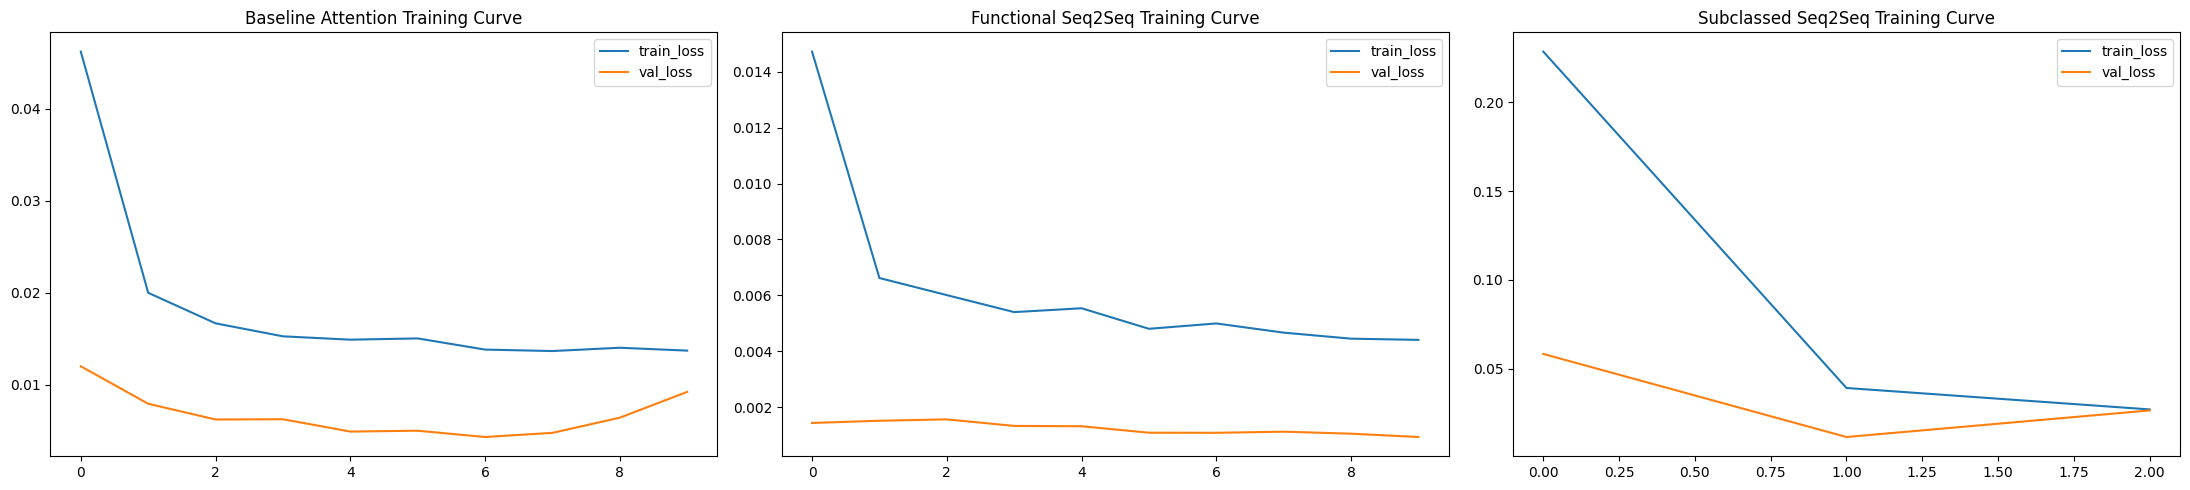

In [114]:
def make_seq2seq_tuple_dataset(encoder_inputs, decoder_inputs, targets, batch_size=BATCH_SIZE, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(((encoder_inputs.astype(np.float32), decoder_inputs.astype(np.float32)), targets.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(encoder_inputs), 2048), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_train, train_decoder_inputs, y_train, shuffle=True)
val_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_val, val_decoder_inputs, y_val, shuffle=False)
test_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_test, test_decoder_inputs, y_test, shuffle=False)

common_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

print('Training baseline attention model...')
history_baseline_attention = baseline_attention_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=common_callbacks,
    verbose=1,
)

print('Training functional seq2seq teacher forcing model...')
history_functional_seq2seq = functional_seq2seq_model.fit(
    train_seq2seq_tuple_ds,
    validation_data=val_seq2seq_tuple_ds,
    epochs=EPOCHS,
    callbacks=common_callbacks,
    verbose=1,
)

print('Training subclassed seq2seq teacher forcing model...')
history_subclassed_seq2seq = subclassed_seq2seq_model.fit(
    train_seq2seq_tuple_ds,
    validation_data=val_seq2seq_tuple_ds,
    epochs=EPOCHS,
    callbacks=common_callbacks,
    verbose=1,
)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
axes[0].plot(history_baseline_attention.history['loss'], label='train_loss')
axes[0].plot(history_baseline_attention.history['val_loss'], label='val_loss')
axes[0].set_title('Baseline Attention Training Curve')
axes[0].legend()

axes[1].plot(history_functional_seq2seq.history['loss'], label='train_loss')
axes[1].plot(history_functional_seq2seq.history['val_loss'], label='val_loss')
axes[1].set_title('Functional Seq2Seq Training Curve')
axes[1].legend()

axes[2].plot(history_subclassed_seq2seq.history['loss'], label='train_loss')
axes[2].plot(history_subclassed_seq2seq.history['val_loss'], label='val_loss')
axes[2].set_title('Subclassed Seq2Seq Training Curve')
axes[2].legend()
plt.tight_layout()
plt.show()
